In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
# 1. Fetch Real Market Data
ticker = "SPY"
start_date = "2021-01-01"
end_date = "2025-12-31" 
data = yf.download(ticker, start=start_date, end=end_date)
data.head(10)


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2021-01-04,343.319183,349.519208,339.623374,349.388863,110210800
2021-01-05,345.683624,346.772829,342.630163,342.676726,66426200
2021-01-06,347.750366,350.943491,343.626336,344.175583,107997700
2021-01-07,352.917023,353.661758,349.947341,350.124221,68766800
2021-01-08,354.927948,355.142045,351.055259,354.304210,71677200
2021-01-11,352.535370,354.294820,351.632363,351.753389,51034700
2021-01-12,352.609894,353.624609,350.366339,352.721630,52547700
2021-01-13,353.559448,354.555526,351.753434,352.535415,45303600


In [13]:

# 2. Calculate daily logarithmic returns
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
returns = data['Log_Return'].dropna().values

mu = np.mean(returns)
sigma = np.std(returns)

print(f"True Distribution: Mu = {mu:.2e}, Sigma = {sigma:.2e}")

True Distribution: Mu = 5.51e-04, Sigma = 1.08e-02


In [14]:
# 3. Define the Rare Event Threshold and Target Probabilities
# We want to estimate the probability of a daily return worse than -5%
threshold = -4.0*sigma  # e.g., 4 standard deviations below the mean 
N_samples = 100000  # Number of Monte Carlo samples

# --- Method A: Standard Monte Carlo (Vanilla) ---
# Sample from the true historical distribution N(mu, sigma)
np.random.seed(42)
standard_samples = np.random.normal(mu, sigma, N_samples)

# Indicator function: 1 if return < threshold, 0 otherwise
indicator_standard = (standard_samples < threshold).astype(float)

# Vanilla Monte Carlo estimate and variance
p_standard = np.mean(indicator_standard)
var_standard = np.var(indicator_standard) / N_samples

# --- Method B: Importance Sampling ---
# Shift the mean to over-sample extreme negative returns (the proposal distribution)
# Proposal distribution: N(mu_prime, sigma) where mu_prime is closer to our threshold
mu_prime = threshold 

# Sample from proposal distribution
proposal_samples = np.random.normal(mu_prime, sigma, N_samples)

# Calculate Importance Weights: w(x) = f(x) / q(x)
# f(x) is true pdf, q(x) is proposal pdf
f_x = norm.pdf(proposal_samples, mu, sigma)
q_x = norm.pdf(proposal_samples, mu_prime, sigma)
weights = f_x / q_x

# Evaluate the rare event condition on proposal samples
indicator_is = (proposal_samples < threshold).astype(float)

# Importance Sampling estimator
weighted_indicators = indicator_is * weights
p_is = np.mean(weighted_indicators)
var_is = np.var(weighted_indicators) / N_samples



--- Results Comparison ---
Vanilla Monte Carlo Probability : 4.00e-05 (Variance: 4.00e-10)
Importance Sampling Probability : 2.57e-05 (Variance: 3.01e-14)
Variance Reduction Factor       : 13294.70x


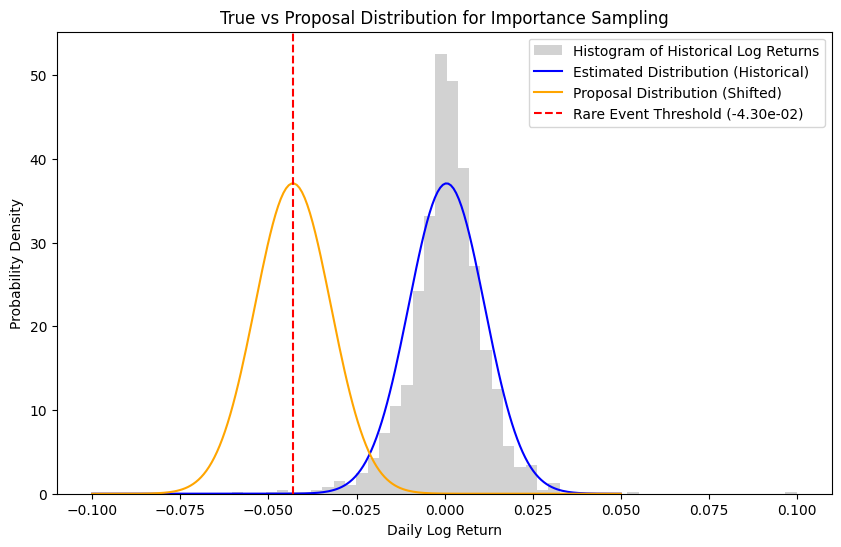

In [17]:
# 4. Results Comparison
print("\n--- Results Comparison ---")
print(f"Vanilla Monte Carlo Probability : {p_standard:.2e} (Variance: {var_standard:.2e})")
print(f"Importance Sampling Probability : {p_is:.2e} (Variance: {var_is:.2e})")
if var_is > 0:
    print(f"Variance Reduction Factor       : {var_standard / var_is:.2f}x")

# 5. Visualization of Distributions
plt.figure(figsize=(10, 6))

# Plot historical log-return histogram on the same axes
plt.hist(
    returns,
    bins=50,
    density=True,
    alpha=0.35,
    color='gray',
    edgecolor='none',
    label='Histogram of Historical Log Returns'
)

# Plot true vs proposal distributions
x = np.linspace(-0.1, 0.05, 200)
plt.plot(x, norm.pdf(x, mu, sigma), label='Estimated Distribution (Historical)', color='blue')
plt.plot(x, norm.pdf(x, mu_prime, sigma), label='Proposal Distribution (Shifted)', color='orange')
plt.axvline(threshold, color='red', linestyle='--', label=f'Rare Event Threshold ({threshold:.2e})')

plt.title('True vs Proposal Distribution for Importance Sampling')
plt.xlabel('Daily Log Return')
plt.ylabel('Probability Density')
plt.legend()
plt.show()
